
# 📘 Day 16: Regression Deep Dive (Theory + Hands-on)

This notebook covers:

- Simple Linear Regression (Salary vs Experience)
- Multiple Linear Regression (Price vs Area + Location + Rooms)
- Polynomial Regression (Non-linear relationships)
- Regularized Regression (Ridge & Lasso)

⚠️ Includes:
- Heavy theory
- Scaling where required
- Industry intuition
- Hands-on code



# 🔹 1. Simple Linear Regression

## Concept

We model relationship between:
- One independent variable (X)
- One dependent variable (y)

### Equation:
y = mx + b

Where:
- m = slope (weight)
- b = intercept

---

## 🧠 Use Case: Salary Prediction

Predict salary based on experience.


Weights: [44.68436695 -6.87184271  1.92585912]
Intercept: 109.16666666666667

Train MSE: 4.501915708812269
Test MSE : 58.21277579601034


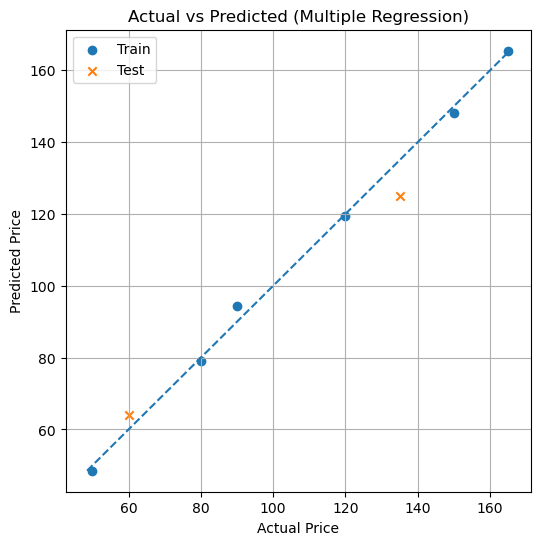

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 🔹 Better dataset (more realistic)
# Features: [area, location, rooms]
X = np.array([
    [1000, 1, 2],
    [1200, 1, 2],
    [1500, 2, 3],
    [1700, 2, 3],
    [2000, 2, 4],
    [2200, 3, 4],
    [2500, 3, 4],
    [2700, 3, 5]
])

y = np.array([50, 60, 80, 90, 120, 135, 150, 165])

# 🔹 Step 1: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 🔹 Step 2: Scaling (NO data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Step 3: Train Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 🔹 Step 4: Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 🔹 Step 5: Evaluation
print("Weights:", model.coef_)
print("Intercept:", model.intercept_)

print("\nTrain MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE :", mean_squared_error(y_test, y_test_pred))

# 🔹 Step 6: Plot (Actual vs Predicted)

plt.figure(figsize=(6,6))

# Train points
plt.scatter(y_train, y_train_pred, marker='o', label="Train")

# Test points
plt.scatter(y_test, y_test_pred, marker='x', label="Test")

# Ideal line (Perfect Prediction)
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.legend()

plt.grid(True)
plt.show()



# 🔹 2. Multiple Linear Regression

## Concept

Multiple features:

y = w1*x1 + w2*x2 + w3*x3 + b

---

## 🧠 Use Case: House Price Prediction

Features:
- Area
- Location (encoded)
- Rooms

⚠️ Scaling is important when features have different ranges.


Weights: [14.73986243 14.84539238 13.2850365 ]
Intercept: 106.66666666666667

Train MSE: 6.731613057885967e-29
Test MSE : 198.55371900826452


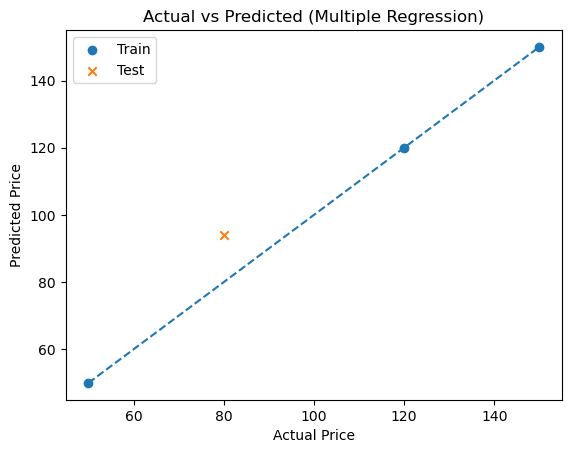

In [19]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Features: [area, location, rooms]
X = np.array([
    [1000, 1, 2],
    [1500, 2, 3],
    [2000, 2, 4],
    [2500, 3, 4]
])

y = np.array([50, 80, 120, 150])

# 🔹 Step 1: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 🔹 Step 2: Scaling (FIT ONLY ON TRAIN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Step 3: Train Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 🔹 Step 4: Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 🔹 Step 5: Evaluation
print("Weights:", model.coef_)
print("Intercept:", model.intercept_)

print("\nTrain MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE :", mean_squared_error(y_test, y_test_pred))

# 🔹 Step 6: Plot (Actual vs Predicted)
plt.scatter(y_train, y_train_pred, label="Train", marker='o')
plt.scatter(y_test, y_test_pred, label="Test", marker='x')

# Ideal line
min_val = min(y.min(), y_train_pred.min())
max_val = max(y.max(), y_train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.legend()
plt.show()




# 🔹 3. Polynomial Regression

## Concept

Used when relationship is non-linear.

Example:
y = ax^2 + bx + c

---

## 🧠 Use Case

- Growth curves
- Demand forecasting


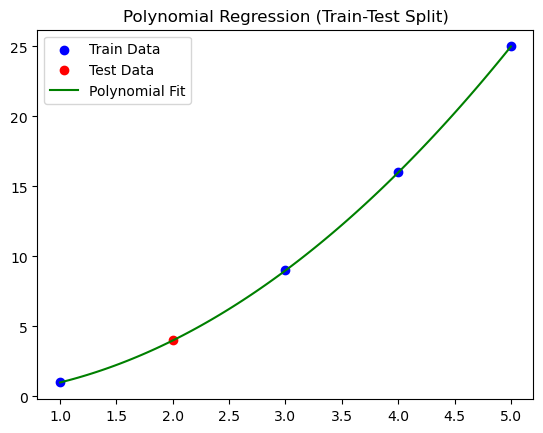

Train MSE: 7.888609052210118e-31
Test MSE : 3.1554436208840472e-30


In [18]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
y = np.array([1, 4, 9, 16, 25])

# 🔹 Step 1: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Step 2: Polynomial Transformation (FIT ONLY ON TRAIN)
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 🔹 Step 3: Train Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 🔹 Step 4: Predictions
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# 🔹 Step 5: Visualization (smooth curve)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

# Plot
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_range, y_range_pred, color='green', label='Polynomial Fit')

plt.title("Polynomial Regression (Train-Test Split)")
plt.legend()
plt.show()

# 🔹 Step 6: Evaluate
from sklearn.metrics import mean_squared_error

train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)

print("Train MSE:", train_error)
print("Test MSE :", test_error)



# 🔹 4. Regularized Regression

## Problem: Overfitting

Model memorizes training data → poor generalization

---

## Ridge Regression (L2)

Adds penalty:
Loss = MSE + λ * (w^2)

---

## Lasso Regression (L1)

Adds penalty:
Loss = MSE + λ * |w|

---

## 🧠 Difference

| Model | Effect |
|------|--------|
| Ridge | Shrinks weights |
| Lasso | Makes some weights zero |


In [17]:

from sklearn.linear_model import Ridge, Lasso

# Sample data
X = np.random.rand(100, 3)
y = X @ np.array([10, 20, 30]) + np.random.randn(100)*2

noise = np.random.rand(100, 1)
X_new = np.hstack([X, noise])

# Scaling is IMPORTANT here
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

from sklearn.linear_model import LinearRegression

linear = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_scaled, y)
lasso.fit(X_scaled, y)
linear.fit(X_scaled, y)

print("Linear Coefficients:", linear.coef_)
print("Ridge Coefficients :", ridge.coef_)
print("Lasso Coefficients :", lasso.coef_)

print("\n--- Shrinkage Comparison ---")
for i in range(len(linear.coef_)):
    print(f"Feature {i}:")
    print(f"  Linear: {linear.coef_[i]:.3f}")
    print(f"  Ridge : {ridge.coef_[i]:.3f}")
    print(f"  Lasso : {lasso.coef_[i]:.3f}")

zero_weights = sum(lasso.coef_ == 0)
print("\nNumber of features removed by Lasso:", zero_weights)

Linear Coefficients: [ 3.43512585  5.79105545  8.19385696 -0.05910695]
Ridge Coefficients : [ 3.40175369  5.72774885  8.11213792 -0.05099857]
Lasso Coefficients : [ 3.33591292  5.67858794  8.08995008 -0.        ]

--- Shrinkage Comparison ---
Feature 0:
  Linear: 3.435
  Ridge : 3.402
  Lasso : 3.336
Feature 1:
  Linear: 5.791
  Ridge : 5.728
  Lasso : 5.679
Feature 2:
  Linear: 8.194
  Ridge : 8.112
  Lasso : 8.090
Feature 3:
  Linear: -0.059
  Ridge : -0.051
  Lasso : -0.000

Number of features removed by Lasso: 1



# 🔥 Mini Project

## Build Your Own Model

Dataset:
- Experience → Salary
- Add noise
- Compare:
    - Linear Regression
    - Polynomial
    - Ridge

👉 Analyze which performs best.
